# Import and definitions

In [1]:
# imports
from matplotlib.ticker import ScalarFormatter
from kuibit.simdir import SimDir
from scipy.integrate import simpson
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numpy import sqrt
import pandas as pd
import numpy as np
import os

In [2]:
# display dynamical plots
%matplotlib widget

In [ ]:
# change the directory to cactus here
CACTUS_ROOT = "/home/undercover/projects/cactus"

In [ ]:
# calls Carpet2ygraphCat.pl to write a 1D quantity from ASCII to plain text, with the format
# ```
#  # time = xxx
#  coord value
#  (...)
# ```
# returns a dictionary with the list of `coord` and `value` for all instants of time
# if there are more than one `output-XXXX`, it appends to the previous timesteps
# if there are overlapping time steps, then the higher output is considered
def GetMesh(sd, quantity, axis):
    coords = {}
    data = {}

    for N in [s.replace("output-", "") for s in os.popen(f"ls {sd.path}").read().split()[1:]]:
        path = f"{sd.path}/output-{N}/{quantity}.{axis}.asc"
        xgpath = f"{sd.path}/output-{N}/{quantity}.{axis}.xg"

        if not os.path.isfile(xgpath):
            os.popen(f"perl {CACTUS_ROOT}/repos/carpet/CarpetIOASCII/src/util/Carpet2ygraphCat.pl {path}")
            os.wait()

        file = open(xgpath, "r")
        file_str = file.read()

        for block in file_str.split("\n\n#")[1:]:
            block = block.split("\n")

            time = block[0].split()[-1]

            N = len(block[1:-1])
            coords[f"t={time}"] = np.empty(N)
            data[f"t={time}"]   = np.empty(N)

            i = 0
            for line in block[1:-1]:
                line = line.split()
                coords[f"t={time}"][i] = float(line[0])
                data[f"t={time}"][i]   = float(line[1])

                i += 1

        file.close()

    return coords, data

# Q-ball potential

/tmp/ipykernel_46221/4171884923.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('copper', len(simulations))


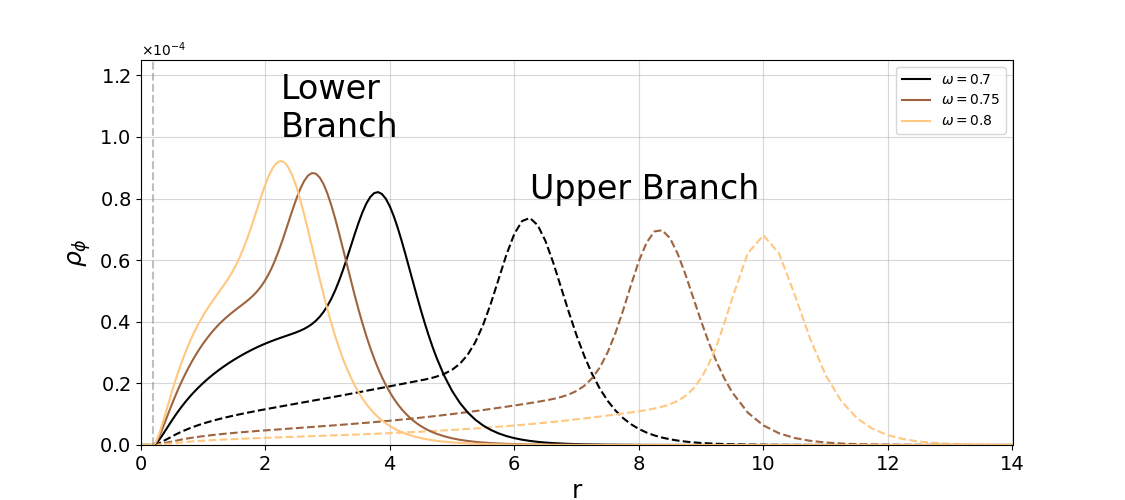

In [14]:
simulations = [
    "alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh=0.2000-w=0.700_h=4",
    "alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh=0.2000-w=0.750_h=4",
    "alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh=0.2000-w=0.800_h=4",
    #"alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh=0.2000-w=0.850_h=4",
    #"alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh=0.2000-w=0.900_h=4",
    #"alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh=0.2000-w=0.950_h=4",
    #"alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh=0.2000-w=1.000_h=4",
]

titles = [
    r"$\omega=0.7$",
    r"$\omega=0.75$",
    r"$\omega=0.8$",
    #r"$\omega=0.85$",
    #r"$\omega=0.9$",
    #r"$\omega=0.95$",
    #r"$\omega=1$",
]

rh = 0.2
plt.suptitle(r"$r_h = 0.2$")

cmap = cm.get_cmap('copper', len(simulations))
colors = [cmap(i) for i in range(len(simulations))]
colors.extend(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(11.25,5))
plt.subplots_adjust(hspace=0.35)

for branch,linestyle in [["upper", "dashed"], ["lower", "solid"]]:
    i = 0

    if branch == "":
        titles = ["" for i in titles]

    for title,simulation in zip(titles,simulations):
        sd = SimDir(f"../simulations/sextic_{branch}_{simulation}")
        ts = sd.timeseries

        coor, data = GetMesh(sd, "rho_phi", "z")

        try:
            if branch == "upper":
                title = ""
            ax1.plot(coor["t=0"], data["t=0"], label=title, color=colors[i], linestyle=linestyle)
        except:
            print(title)

        i += 1

# set the y-axis to scientific notation
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))  # not sure what this does...
ax1.yaxis.set_major_formatter(formatter)

# print text for each branches
ax1.text(2.25, 0.0001,  "Lower\nBranch", fontsize=24, rotation=0)
ax1.text(6.25, 0.00008, "Upper Branch",  fontsize=24, rotation=0)

# horizon location
plt.axvline(x=rh, color='grey', linestyle='--', alpha=0.5)

# make plot pretty
ax1.grid(alpha=0.5)
ax1.set_xlim((0,14))
ax1.set_ylim((0,0.000125))
ax1.set_xlabel("r", fontsize=18)
ax1.set_ylabel(r"$\rho_\phi$", fontsize=18)
ax1.tick_params(axis='both', labelsize=14)
ax1.legend();

/tmp/ipykernel_14608/1634837494.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('copper', len(simulations))


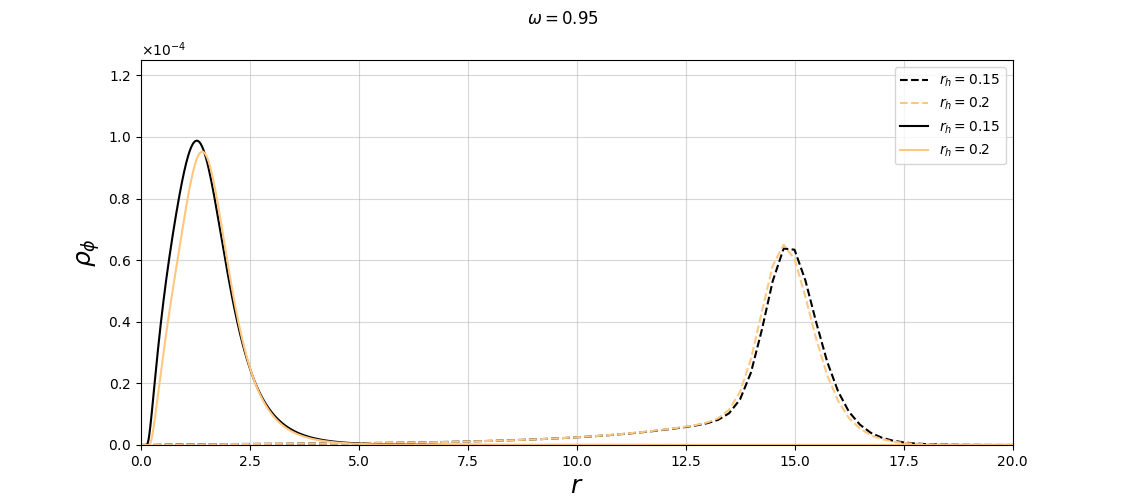

In [6]:
simulations = [
    "alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh=0.1500-w=0.950_h=4",
    "alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh=0.2000-w=0.950_h=4",
]

titles = [
    r"$r_h = 0.15$",
    r"$r_h = 0.2$",
]

cmap = cm.get_cmap('copper', len(simulations))
colors = [cmap(i) for i in range(len(simulations))]
colors.extend(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(11.25,5))
plt.subplots_adjust(hspace=0.35)

for branch,linestyle in [["upper", "dashed"], ["lower", "solid"]]:
    i = 0

    if branch == "":
        titles = ["" for i in titles]

    for title,simulation in zip(titles,simulations):
        sd = SimDir(f"../simulations/sextic_{branch}_{simulation}")
        ts = sd.timeseries

        coor, data = GetMesh(sd, "rho_phi", "z")

        try:
            ax1.plot(coor["t=0"], data["t=0"], label=title, color=colors[i], linestyle=linestyle)
        except:
            print(title)

        i += 1

# set the y-axis to scientific notation
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))  # not sure what this does...
ax1.yaxis.set_major_formatter(formatter)

# print text for each branches
#ax1.text(2.25, 0.0001,  "Lower\nBranch", fontsize=24, rotation=0)
#ax1.text(6.25, 0.00008, "Upper Branch",  fontsize=24, rotation=0)

# make plot pretty
plt.suptitle(r"$\omega = 0.95$")
ax1.grid(alpha=0.5)
ax1.set_xlim((0,20))
ax1.set_ylim((0,0.000125))
ax1.set_xlabel(r"$r$",         fontsize=18)
ax1.set_ylabel(r"$\rho_\phi$", fontsize=18)
ax1.legend();

# Axionic potential

/tmp/ipykernel_457885/2082009786.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('copper', len(simulations))


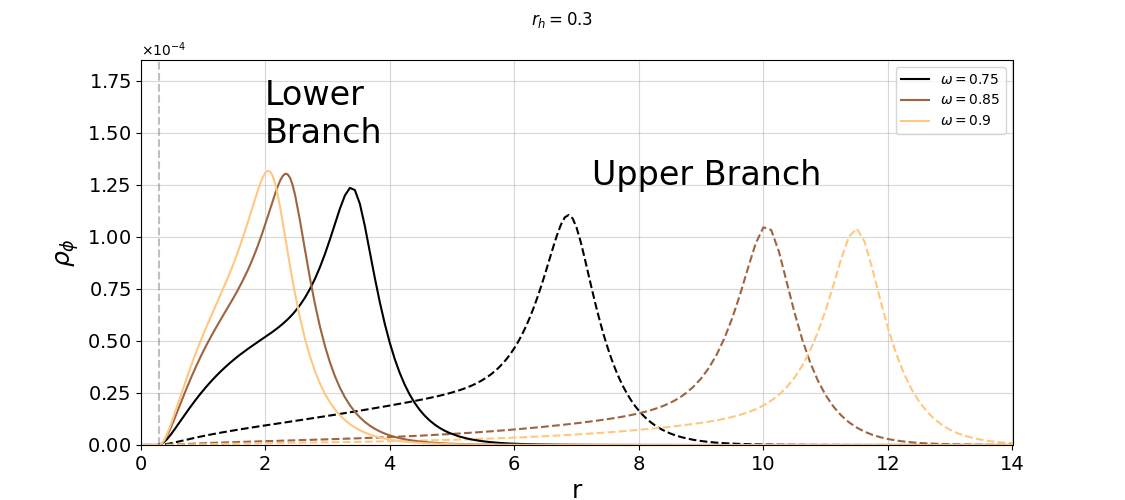

In [ ]:
simulations = [
    "alpha=1-q=3-mu=1-B=0.22-fa=0.01-rh=0.3000-w=0.750",
    "alpha=1-q=3-mu=1-B=0.22-fa=0.01-rh=0.3000-w=0.850",
    "alpha=1-q=3-mu=1-B=0.22-fa=0.01-rh=0.3000-w=0.900"
]

titles = [
    r"$\omega=0.75$",
    r"$\omega=0.85$",
    r"$\omega=0.9$"
]

cmap = cm.get_cmap('copper', len(simulations))
colors = [cmap(i) for i in range(len(simulations))]
colors.extend(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(11.25,5))
rh = 0.3
plt.suptitle(r"$r_h = 0.3$")
plt.subplots_adjust(hspace=0.35)

for branch,linestyle,resolution in [["upper", "dashed", "h=2"], ["lower", "solid", "h=5.12"]]:
    i = 0

    if branch == "":
        titles = ["" for i in titles]

    for title,simulation in zip(titles,simulations):
        sd = SimDir(f"../simulations/axionic_{branch}_{simulation}_{resolution}")
        ts = sd.timeseries

        coor, data = GetMesh(sd, "rho_phi", "z")

        try:
            if branch == "upper":
                title = ""
            ax1.plot(coor["t=0"], data["t=0"], label=title, color=colors[i], linestyle=linestyle)
        except:
            print(title)

        i += 1

# set the y-axis to scientific notation
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))  # not sure what this does...
ax1.yaxis.set_major_formatter(formatter)

# print text for each branches
ax1.text(2., 0.000145,  "Lower\nBranch", fontsize=24, rotation=0)
ax1.text(7.25, 0.000125, "Upper Branch",  fontsize=24, rotation=0)

# horizon location
plt.axvline(x=rh, color='grey', linestyle='--', alpha=0.5)

# make plot pretty
ax1.grid(alpha=0.5)
ax1.set_xlim((0,14))
ax1.set_ylim((0,0.000185))
ax1.set_xlabel("r", fontsize=18)
ax1.set_ylabel(r"$\rho_\phi$", fontsize=18)
ax1.tick_params(axis='both', labelsize=14)
ax1.legend();